In [1]:
import pandas as pd
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sam_sub = pd.read_csv("sample_submission.csv")

In [2]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7920 entries, 0 to 7919
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      7920 non-null   int64 
 1   label   7920 non-null   int64 
 2   tweet   7920 non-null   object
dtypes: int64(2), object(1)
memory usage: 185.8+ KB


In [3]:
train["label"].value_counts()

0    5894
1    2026
Name: label, dtype: int64

# Data Cleaning

In [4]:
import re
def clean_tweet(text):

  # take off html tags
  text = BeautifulSoup(text).get_text()
  
  # fetch alphabetic characters
  text = re.sub("[^a-zA-Z]", " ", text)

  # convert text to lower case
  text = text.lower()

  # split text into tokens to remove whitespaces
  tokens = text.split()

  return " ".join(tokens)

In [5]:
train["clean_tweet"] = train['tweet'].apply(clean_tweet)
test["clean_tweet"] =  test['tweet'].apply(clean_tweet)

In [6]:

train["clean_tweet"][2]

'we love this would you go talk makememories unplug relax iphone smartphone wifi connect http fb me n lsupcu'

In [7]:
train["tweet"][2]

'We love this! Would you go? #talk #makememories #unplug #relax #iphone #smartphone #wifi #connect... http://fb.me/6N3LsUpCu'

# Plotting the tokens of the clean data , to identify the maximum  tokens

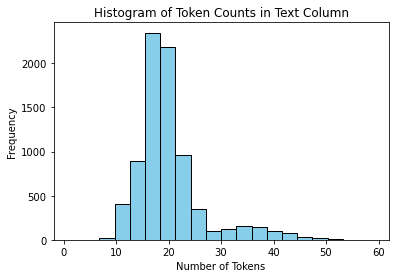

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
tokens = train['clean_tweet'].apply(word_tokenize)
token_counts = [len(token_list) for token_list in tokens]
plt.hist(token_counts, bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Token Counts in Text Column')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.show()

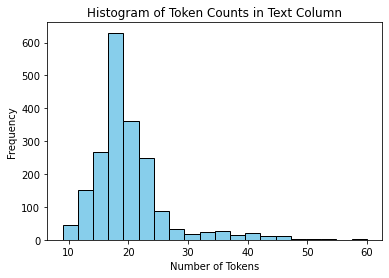

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
tokens = test['clean_tweet'].apply(word_tokenize)
token_counts = [len(token_list) for token_list in tokens]
plt.hist(token_counts, bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Token Counts in Text Column')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.show()

# Using BERT for embeddings

In [10]:
#!pip install transformers 
#!pip install seaborn numpy scipy

In [80]:
import tensorflow as tf
from transformers import BertTokenizer,BertModel ,TFBertModel
# from tensorflow.keras.layers import Input, Dense
# from tensorflow.keras.models import Model
# from tensorflow.keras.optimizers import Adam
# from keras.callbacks import EarlyStopping
# import torch

In [82]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
#tf_bert_model = TFBertModel.from_pretrained('bert-base-uncased',from_pt=True)
bert_model = BertModel.from_pretrained('bert-base-uncased')

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already

In [83]:
def embed_text(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=60)
    outputs = bert_model(**inputs)
    embeddings = torch.mean(outputs.last_hidden_state, dim=1)  # Pooling, you can use other strategies
    return embeddings.detach().numpy()
train['embeddings'] = train['clean_tweet'].apply(embed_text)
train['flattened_embeddings'] = train['embeddings'].apply(lambda x: x.flatten())

In [84]:
test['embeddings'] = test['clean_tweet'].apply(embed_text)
test['flattened_embeddings'] = test['embeddings'].apply(lambda x: x.flatten())

# Plotting confuusion matrix

In [86]:
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
import seaborn as sns
def plot_confusion_matrix(model,X_test,y_test,y_pred):
    #model = models['Naive Bayes']
    #y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    class_labels = ['Class 0', 'Class 1']  # Replace with your class labels

    # Create a heatmap of the confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

    # Add labels and title
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()


In [79]:
# # Sample data (replace with your own)
# X_train, X_test, y_train, y_test = train_test_split(train["clean_tweet"], train["label"], test_size=0.2, random_state=42)

# # Load BERT model
# bert_model = TFBertModel.from_pretrained('bert-base-uncased',from_pt=True)

# # Tokenizer
# tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# # Tokenize inputs
# def tokenize_inputs(texts, tokenizer, max_length):
#     tokenized_texts = tokenizer(texts.tolist(), max_length=max_length, padding='max_length', truncation=True, return_tensors="tf")
#     return {
#         'input_ids': tokenized_texts['input_ids'],
#         'attention_mask': tokenized_texts['attention_mask']
#     }

# max_seq_length = 60
# X_train_tokens = tokenize_inputs(X_train, tokenizer, max_seq_length)
# X_test_tokens = tokenize_inputs(X_test, tokenizer, max_seq_length)

# # Define model architecture
# input_ids = Input(shape=(max_seq_length,), dtype=tf.int32, name="input_ids")
# attention_mask = Input(shape=(max_seq_length,), dtype=tf.int32, name="attention_mask")

# bert_output = bert_model(input_ids, attention_mask=attention_mask)[1]  # Using only the pooled_output
# dense_layer = Dense(128, activation='relu')(bert_output)
# output = Dense(1, activation='softmax')(dense_layer)

# model = Model(inputs=[input_ids, attention_mask], outputs=output)

# # Compile model
# optimizer = Adam(learning_rate=1e-5)
# model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# # Train model
# batch_size = 32
# epochs = 5

# model.fit(
#     x=X_train_tokens,
#     y=y_train,
#     validation_data=(X_test_tokens, y_test),
#     batch_size=batch_size,
#     epochs=epochs
# )

In [89]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification

In [124]:
X = torch.tensor(np.stack(train['flattened_embeddings'].to_numpy()))
y = torch.tensor(train['label'].to_numpy())
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

class MLPClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLPClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(hidden_size, output_size)
        #self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        #x = self.softmax(x)
        return x
# Set hyperparameters
input_size = X_train.shape[1]
hidden_size = 128
output_size = 2 
model = MLPClassifier(input_size, hidden_size, output_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training loop
num_epochs = 150
batch_size = 32
for epoch in range(num_epochs):
    for i in range(0, len(X_train), batch_size):
        inputs = X_train[i:i + batch_size]
        labels = y_train[i:i + batch_size]

        # Forward pass
        outputs = model(inputs.float())
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Print the loss after each epoch
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')


Epoch [1/150], Loss: 0.6995
Epoch [2/150], Loss: 0.6867
Epoch [3/150], Loss: 0.6866
Epoch [4/150], Loss: 0.6477
Epoch [5/150], Loss: 0.7035
Epoch [6/150], Loss: 0.7630
Epoch [7/150], Loss: 0.7268
Epoch [8/150], Loss: 0.6124
Epoch [9/150], Loss: 0.5985
Epoch [10/150], Loss: 0.6986
Epoch [11/150], Loss: 0.6075
Epoch [12/150], Loss: 0.6339
Epoch [13/150], Loss: 0.6585
Epoch [14/150], Loss: 0.6162
Epoch [15/150], Loss: 0.5956
Epoch [16/150], Loss: 0.5877
Epoch [17/150], Loss: 0.5689
Epoch [18/150], Loss: 0.5395
Epoch [19/150], Loss: 0.4698
Epoch [20/150], Loss: 0.5003
Epoch [21/150], Loss: 0.4794
Epoch [22/150], Loss: 0.4811
Epoch [23/150], Loss: 0.4804
Epoch [24/150], Loss: 0.5143
Epoch [25/150], Loss: 0.4832
Epoch [26/150], Loss: 0.5266
Epoch [27/150], Loss: 0.4618
Epoch [28/150], Loss: 0.4253
Epoch [29/150], Loss: 0.3868
Epoch [30/150], Loss: 0.4161
Epoch [31/150], Loss: 0.3744
Epoch [32/150], Loss: 0.3362
Epoch [33/150], Loss: 0.3642
Epoch [34/150], Loss: 0.3557
Epoch [35/150], Loss: 0

Validation Accuracy: 88.80%
Plotting Confusion Matrix.....


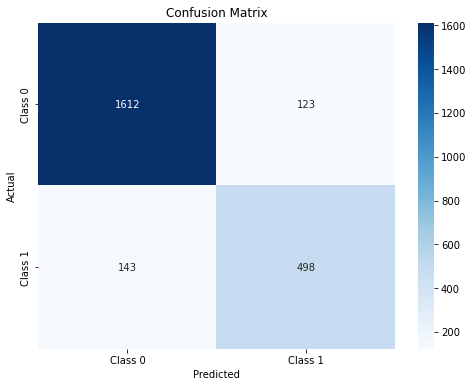

In [125]:
with torch.no_grad():
    model.eval()
    outputs = model(X_val.float())
    _, predicted = torch.max(outputs, 1)
    accuracy = (predicted == y_val).sum().item() / y_val.size(0)
    print(f'Validation Accuracy: {accuracy * 100:.2f}%')
    print("Plotting Confusion Matrix.....")
    plot_confusion_matrix(model,X_val,y_val,predicted)

In [126]:
X_test = torch.tensor(np.stack(test['flattened_embeddings'].to_numpy()))
#y = torch.tensor(train['label'].to_numpy())
pred_result= []
with torch.no_grad():
    model.eval()
    outputs = model(X_test.float())
    _, predicted = torch.max(outputs, 1)
    pred_result.append(predicted.tolist())
    #accuracy = (predicted == y_val).sum().item() / y_val.size(0)
    #print(f'Validation Accuracy: {accuracy * 100:.2f}%')
    #print("Plotting Confusion Matrix.....")
    #plot_confusion_matrix(model,X_val,y_val,predicted)

In [127]:
sam_sub["label"] = pred_result[0]

In [128]:
sam_sub.to_csv("sam_sub-pred.csv",index=False)

In [120]:
test.shape

(1953, 5)